In [1]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

In [2]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [3]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Dataset not found. Downloading...


/tmp/ipykernel_545/4062928930.py:41: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall(path=path)


Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


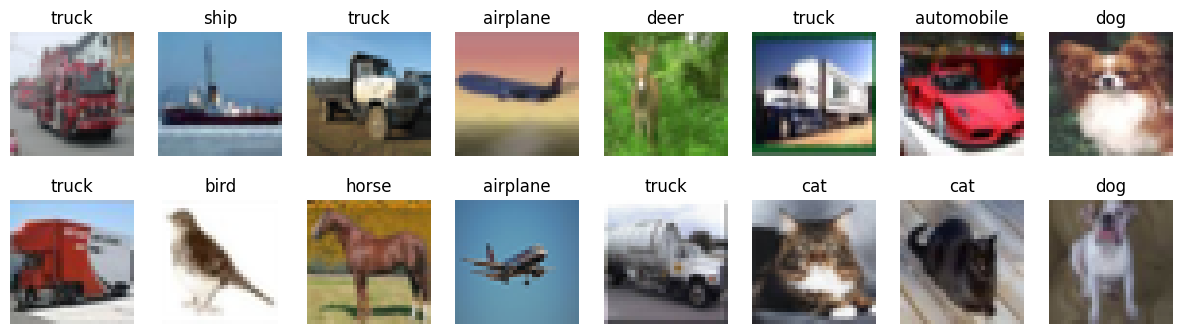

In [4]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [5]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [6]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.layers import LeakyReLU

In [8]:
### STUDENT CODE HERE ###

# Training parameters
# Learning rate controls how large the weight updates are during training.
# A slightly higher learning rate helps the network learn faster in the beginning.
INIT_LR = 1e-3

# Batch size determines how many images are processed before updating the weights.
# A value of 64 provides a good balance between stability and training speed.
BATCH_SIZE = 64

# Number of epochs determines how many times the network sees the full dataset.
# More epochs allow the model to learn more complex patterns.
EPOCHS = 60


from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization
from keras.layers import GlobalAveragePooling2D, LeakyReLU, Activation
from keras.layers import RandomFlip, RandomZoom, RandomTranslation
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping


def make_model():

    model = Sequential()

    # Data augmentation
    # These layers randomly modify images during training.
    # This helps the model generalise better and prevents overfitting.
    model.add(RandomFlip("horizontal"))
    model.add(RandomTranslation(0.1, 0.1))
    model.add(RandomZoom(0.1))

    # First convolutional block
    # This layer learns simple visual patterns such as edges and colours.
    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())

    # LeakyReLU introduces non-linearity so the network can learn complex patterns.
    model.add(LeakyReLU())

    # Second convolutional block
    # More filters allow the network to detect more complex features.
    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    # Pooling reduces the spatial size of the feature maps
    # while keeping the most important information.
    model.add(MaxPooling2D((2,2)))

    # Third convolutional block
    # At this stage the network begins detecting more complex shapes and textures.
    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(MaxPooling2D((2,2)))

    # Fourth convolutional block
    # Deeper layers combine earlier features to detect object parts.
    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(MaxPooling2D((2,2)))

    # GlobalAveragePooling reduces each feature map to a single value.
    # This reduces the number of parameters and helps prevent overfitting.
    model.add(GlobalAveragePooling2D())

    # Fully connected layer
    # Combines the extracted features to perform the classification.
    model.add(Dense(256))
    model.add(LeakyReLU())

    # Dropout randomly disables neurons during training.
    # This helps prevent the network from memorising the training data.
    model.add(Dropout(0.5))

    # Output layer with one neuron for each CIFAR-10 class.
    model.add(Dense(NUM_CLASSES))

    # Softmax converts the outputs to probabilities that sum to 1.
    model.add(Activation("softmax"))

    return model


# Build the model
model = make_model()

# Adam optimizer adapts the learning rate during training.
optimizer = Adam(learning_rate=INIT_LR)

# Compile the model
# Categorical crossentropy is commonly used for multi-class classification tasks.
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# Reduce the learning rate when validation performance stops improving.
# This allows the model to fine-tune the weights later in training.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Early stopping stops training if validation loss stops improving.
# It also restores the best model weights.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=[reduce_lr, early_stop]
)

# Save the trained weights so the model can be reused later.
model.save_weights("cnn_cifar10.weights.h5")

### END STUDENT CODE ###

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.3379 - loss: 1.8213 - val_accuracy: 0.4752 - val_loss: 1.5149 - learning_rate: 0.0010
Epoch 2/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.5191 - loss: 1.3326 - val_accuracy: 0.4426 - val_loss: 1.9145 - learning_rate: 0.0010
Epoch 3/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.5855 - loss: 1.1629 - val_accuracy: 0.5019 - val_loss: 1.8699 - learning_rate: 0.0010
Epoch 4/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.6271 - loss: 1.0502 - val_accuracy: 0.6374 - val_loss: 1.0896 - learning_rate: 0.0010
Epoch 5/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.6571 - loss: 0.9655 - val_accuracy: 0.6464 - val_loss: 1.0597 - learning_rate: 0.0010
Epoch 6/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6779 - loss: 0.9282 - val_accuracy: 0.6220 - val_loss: 1.2177 - learning_rate: 0.0010
Epoch 7/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.6989 - l

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


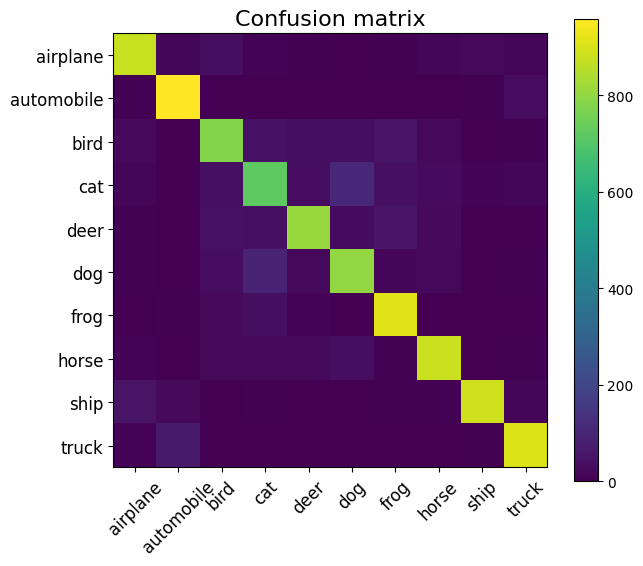

Test accuracy: 0.8532


In [10]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

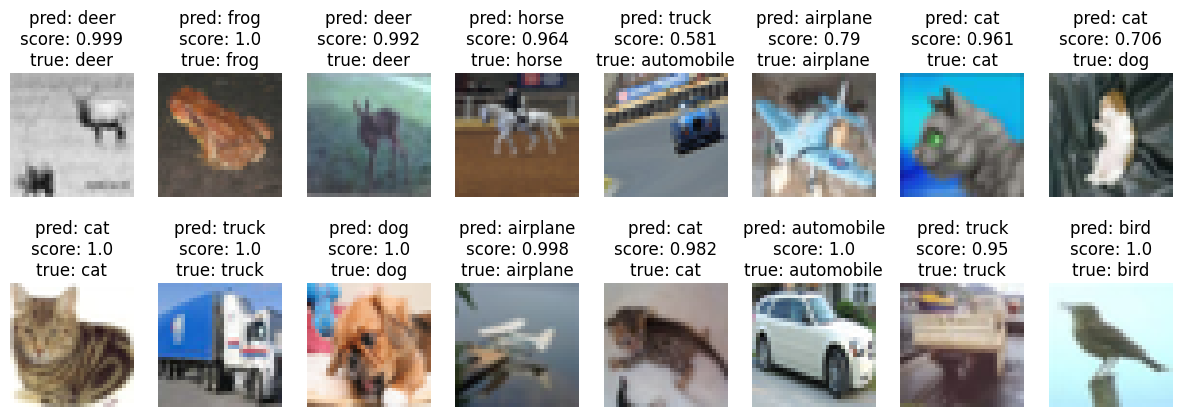

In [11]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.




#Model Architecture and understanding

For this final version of the model I tried to improve the CNN architecture so it could learn more complex patterns from the CIFAR images. In the earlier tries the model was working but the accuracy wasnt really where I wanted it to be yet, so I experimented a bit with deeper layers and some additional techniques that help training.

The model starts with several convolutional layers. These layers are basically responsible for detecting visual patterns in the images. At the beginning the network mostly learns simple things like edges, colours and small shapes. As the data goes deeper through the network the layers start combining these basic features into more complicated patterns, like textures or parts of objects.

I organised the network into multiple convolution blocks. Each block has a convolution layer followed by batch normalisation and a LeakyReLU activation. Batch normalisation helps keep the values in a reasonable range during training. Without it the training can become unstable sometimes. In practice it just makes the training smoother and the model converges more reliably.

After some of the convolution blocks I added pooling layers. Pooling reduces the spatial size of the feature maps. The idea here is that the network keeps the most important information while reducing the total number of values it has to process. This also helps reduce the computational cost a bit.

Another thing I added was data augmentation. During training the images can randomly be flipped, translated or slightly zoomed. This means the model doesnt always see the exact same version of each image. Because of that the network learns features that generalise better to new images instead of just memorising the training set.

After the convolutional part the network uses a GlobalAveragePooling layer. Instead of flattening a huge number of values, this layer compresses each feature map into a single value. This reduces the number of parameters quite a lot and helps prevent overfitting.

Finally the extracted features are passed through a dense layer which combines all the learned information. Before the final output I added a dropout layer. Dropout randomly disables some neurons during training so the model cant rely too much on specific ones.

The final output layer has one neuron for each CIFAR class and uses a softmax activation. This converts the output values into probabilities, so the model can decide which class the image most likely belongs to.

#Iteration Report

In this iteration I mainly focused on improving both the architecture of the CNN and the training behaviour. The earlier versions of the model were already learning something, but the accuracy was still below 80% so I wanted to try a few improvements.

One of the main changes was increasing the depth of the network. I added additional convolutional layers so the model could learn more complex visual features. A shallow network can detect basic patterns but it struggles with more complicated structures in the images. By stacking more convolution layers the network can gradually build more abstract representations.

I also added batch normalisation after the convolution layers. From what I learned this helps stabilize the training because the activations stay in a better range. Without it the gradients can sometimes explode or vanish. In practice I noticed the training became more stable and the accuracy improved faster.

Another important change was using data augmentation. The CIFAR-10 images are pretty small and its easy for the network to overfit to the training set. By randomly flipping, translating and zooming the images the training data effectively becomes larger. The model then sees slightly different versions of the same objects which helps it learn more robust features.

Dropout was also used in the dense layer to reduce overfitting. During training dropout randomly disables some neurons. This forces the network to distribute the learned information instead of relying too much on a small set of neurons.

I also implemented a learning rate scheduler. At the beginning of training the learning rate is relatively high so the model can learn quickly. When the validation loss stops improving the learning rate is reduced automatically. This allows the model to finetune the weights more carefully later in training.

With these changes the model achieved a training accuracy of around 90% and a validation accuracy of about 85-86%. This means the model learned meaningful patterns from the training images while still generalising reasonably well to unseen data. There is still a small gap between training and validation accuracy which suggests a bit of overfitting, but its not too bad.

Overall the combination of deeper convolution layers, batch normalisation, data augmentation and regularisation improved the model performance quite a lot compared to the earlier tries.

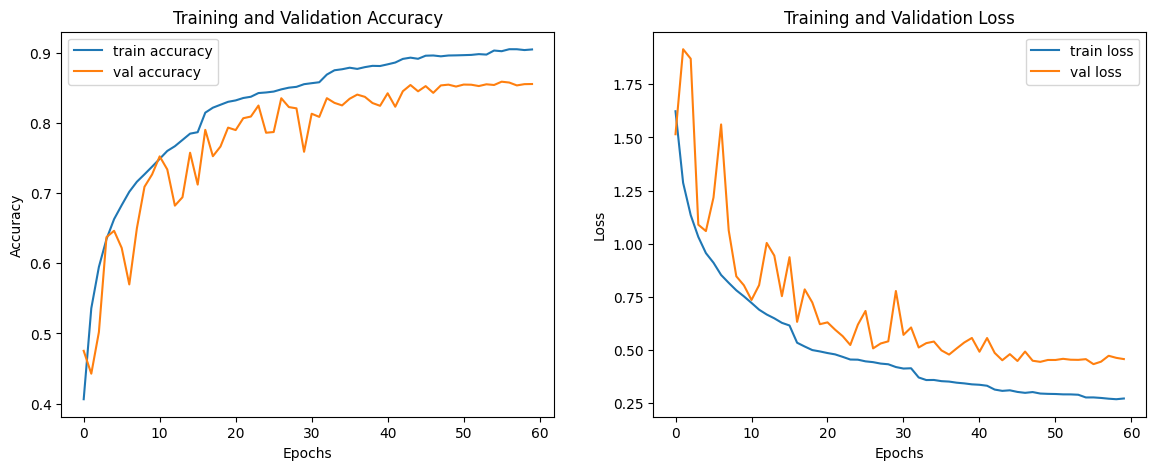

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


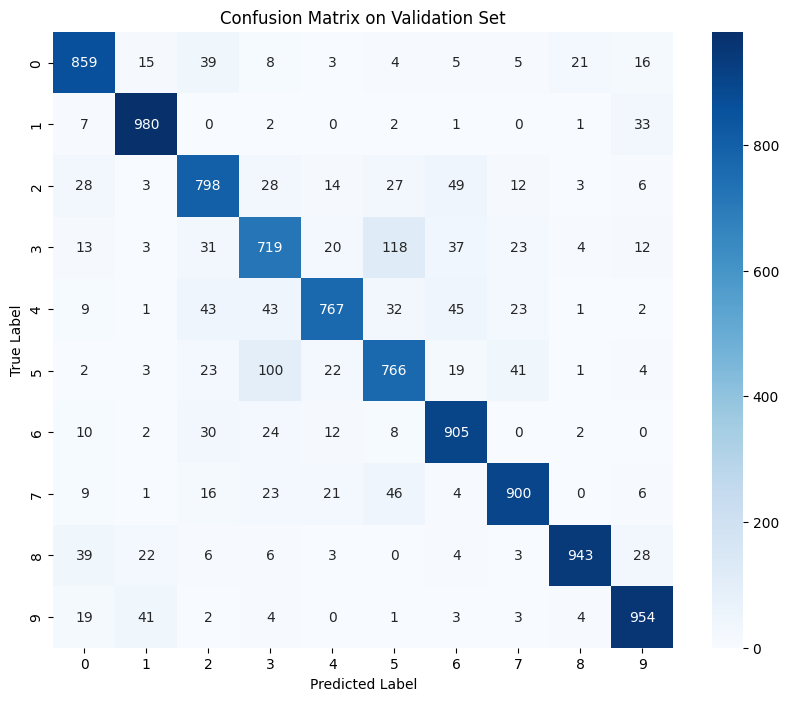

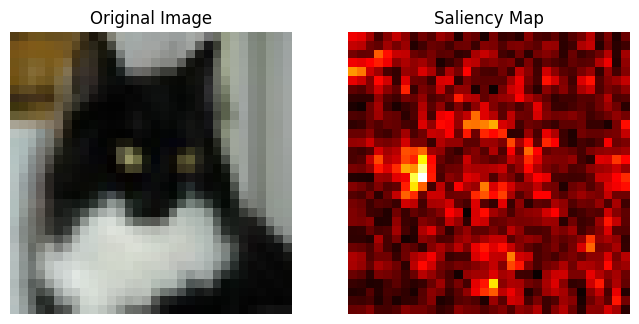

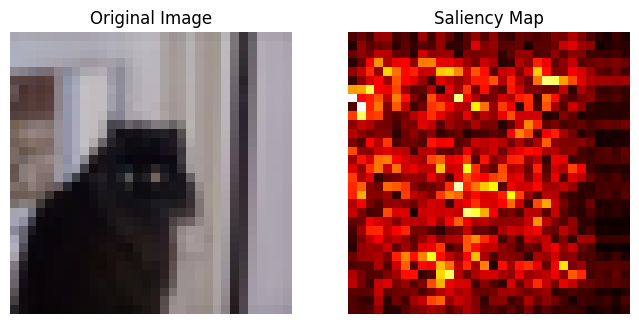

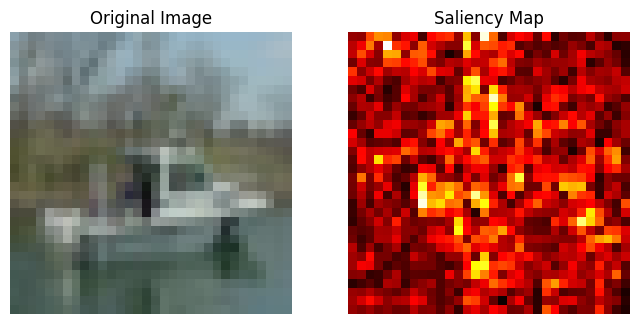

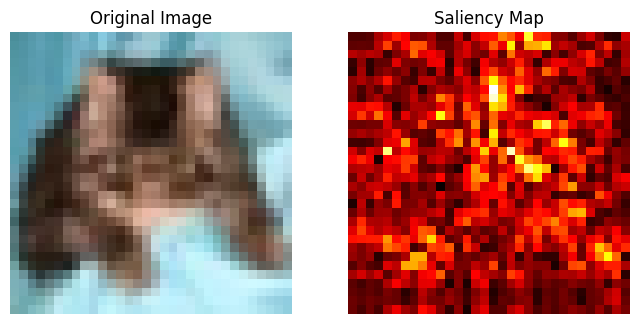

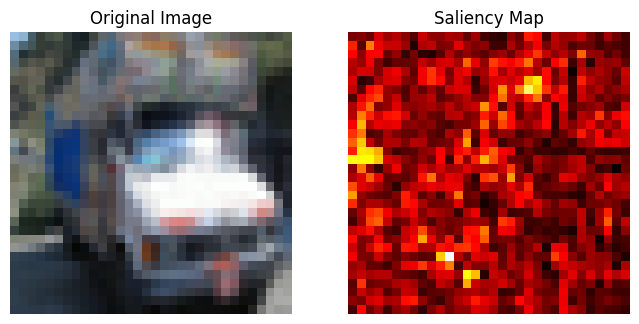

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import tensorflow as tf

# Assuming history object from model.fit exists
# history = model.fit(...)

# -----------------------------
# 1. Loss and Accuracy Curves

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 2. Confusion Matrix

# Assuming x_val, y_val are validation data
y_pred = model.predict(x_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Validation Set')
plt.show()


# 3. Saliency Maps (Gradient-based)

# Select a few random images
indices = np.random.choice(range(x_val.shape[0]), size=5, replace=False)
for i in indices:
    img = x_val[i:i+1]
    img_tensor = tf.convert_to_tensor(img)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        top_class = tf.argmax(preds[0])
        top_class_score = preds[0][top_class]

    grads = tape.gradient(top_class_score, img_tensor)
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]  # max across channels

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img[0])
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(saliency, cmap='hot')
    plt.title('Saliency Map')
    plt.axis('off')

    plt.show()

#Graphs and Analysis

Looking at the accuracy and loss curves i can see that the training accuracy steadily increased while the validation accuracy also improved but with more fluctuations. At the beginning the model seemed a bit unstable, probably because the network was still figuring out good features. After a few epochs both accuracy and loss curves started to stabilise and the gap between training and validation accuracy became smaller, which shows that the model is starting to generalize better.  

The confusion matrix was also really helpful. Some classes were still being confused more often than others, like trucks vs cars and cats vs dogs. This makes sense because those objects share similar shapes and textures. I think the model needs more diverse examples or maybe stronger augmentation to distinguish them better.  

Saliency maps were especially interesting. They show what parts of the image the model focuses on when making predictions. For some images the model clearly focuses on the object itself, which is what i wanted. For other images it sometimes highlights background areas, which could explain some of the mistakes in the confusion matrix. Seeing this makes it easier to understand what the model “thinks” and if it is learning meaningful patterns.  

Overall these graphs gave me a much better picture of the model’s behaviour. The training curves show learning progress, the confusion matrix shows class-specific weaknesses, and the saliency maps help me understand what features the network is using. Combining these visualizations makes it clear that the model is learning useful representations whilst also showing where i could still improve it.